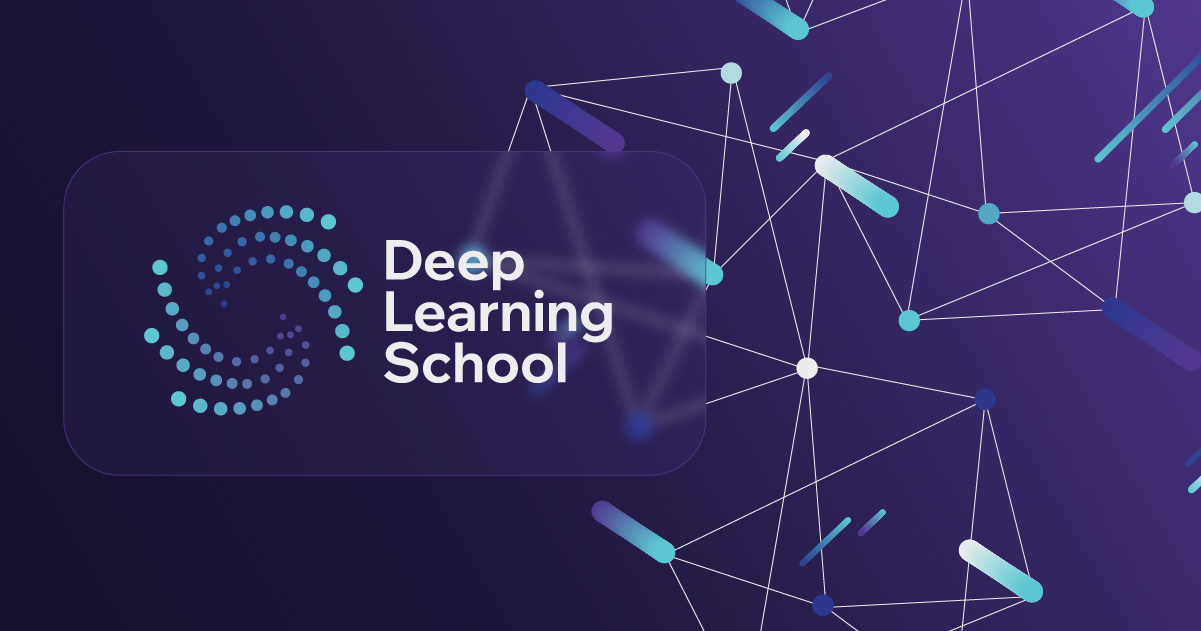

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

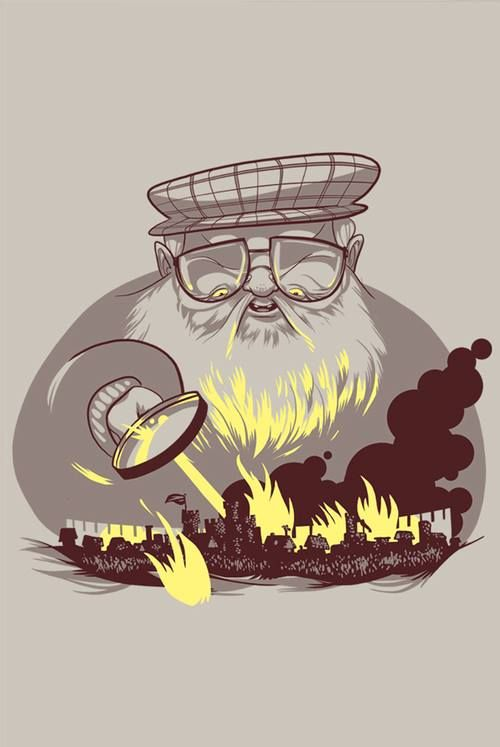

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 19.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 33.7MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [4]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')

In [5]:
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


Посмотрите, какие типы данных представлены в нашем датасете

In [6]:
data.dtypes

,0
name,object
title,object
male,int64
culture,object
dateOfBirth,float64
mother,object
father,object
heir,object
house,object
spouse,object


Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [7]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [8]:
data.describe(include = [np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [9]:
data.shape

(1557, 25)

In [10]:
data.isna().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

<Axes: >

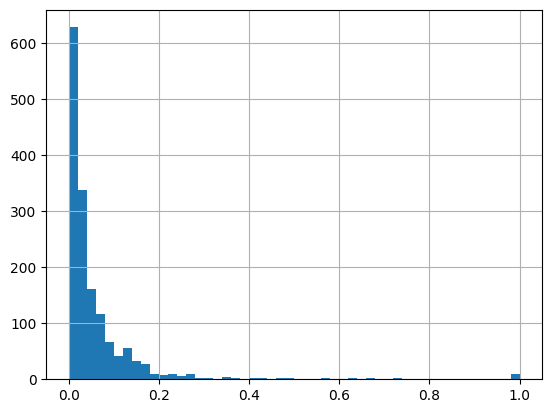

In [11]:
data['popularity'].hist(bins=50)

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


In [12]:
data_popularity_log = np.log10(data["popularity"] * 100 + 1)

<Axes: >

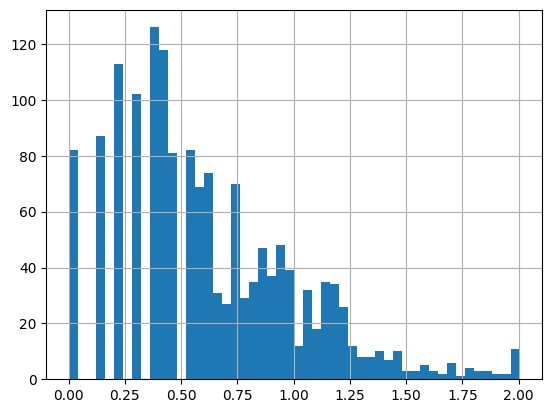

In [13]:
data_popularity_log.hist(bins=50)

В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

In [14]:
data_popularity_qcut = pd.qcut(data["popularity"], 5)

In [15]:
data_popularity_qcut

,popularity
S.No,
1,"(0.0803, 1.0]"
2,"(0.0803, 1.0]"
3,"(0.0803, 1.0]"
4,"(0.0803, 1.0]"
5,"(0.0355, 0.0803]"
...,...
1553,"(0.0803, 1.0]"
1554,"(0.0355, 0.0803]"
1555,"(0.0355, 0.0803]"


In [16]:
pd.get_dummies(data_popularity_qcut)

,"(-0.001, 0.01]","(0.01, 0.0167]","(0.0167, 0.0355]","(0.0355, 0.0803]","(0.0803, 1.0]"
S.No,,,,,
1,False,False,False,False,True
2,False,False,False,False,True
3,False,False,False,False,True
4,False,False,False,False,True
5,False,False,False,True,False
...,...,...,...,...,...
1553,False,False,False,False,True
1554,False,False,False,True,False
1555,False,False,False,True,False


In [17]:
data["popularity"] = np.log10(data["popularity"] * 100 + 1)

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [18]:
data[data['numDeadRelations'] > 0].shape

(69, 25)

In [19]:
data.shape

(1557, 25)

In [20]:
data['boolDeadRelations'] = np.where(data['numDeadRelations'] > 0, True, False)

In [21]:
data = data.drop('numDeadRelations', axis=1)

Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [22]:
data['age_value'] = [age if not np.isnan(age) else 0 for age in data['age']]
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

In [23]:
data = data.drop('age', axis=1)

Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

In [24]:
data['dateOfBirth_value'] = [date if not np.isnan(date) else 0 for date in data['dateOfBirth']]

In [25]:
data = data.drop('dateOfBirth', axis=1)

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [26]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [27]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [28]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [29]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped
cultures_grouped_inverted = dict()
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
      cultures_grouped_inverted.update({v:k})
cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [30]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [31]:
data['culture_grouped']

,culture_grouped
S.No,
1,NaN
2,the Isles and Rivers
3,NaN
4,NaN
5,Dorne
...,...
1553,NaN
1554,NaN
1555,NaN


In [32]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

In [33]:
data['culture_grouped']

,culture_grouped
S.No,
1,culture_no_data
2,the Isles and Rivers
3,culture_no_data
4,culture_no_data
5,Dorne
...,...
1553,culture_no_data
1554,culture_no_data
1555,culture_no_data


In [34]:
data = data.drop('culture', axis=1)

Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [35]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
mother,16
father,19
heir,20
house,315
spouse,186
book1,2
book2,2


In [36]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include = [np.number]).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.000000,2
book1,1557.0,0.0,1.000000,2
book2,1557.0,0.0,1.000000,2
book3,1557.0,0.0,1.000000,2
book4,1557.0,0.0,1.000000,2
book5,1557.0,0.0,1.000000,2
isAliveMother,18.0,0.0,1.000000,2
isAliveFather,22.0,0.0,1.000000,2
isAliveHeir,21.0,0.0,1.000000,2
isAliveSpouse,200.0,0.0,1.000000,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [37]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:

data.groupby('isAliveSpouse', dropna = False)['isAlive'].mean()
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveSpouse', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

Анализируем количественные признаки

In [38]:
pd.DataFrame([data.select_dtypes(include='object').isna().sum(),
              data.select_dtypes(include='object').nunique(),
              data.select_dtypes(include='object').count(),
              data.select_dtypes(include='object').isna().sum() / data.shape[0] * 100,
              data.select_dtypes(include='object').nunique() / data.shape[0] * 100],
             index=['nan', 'unique', 'count', '% nan', '% unique'])

,name,title,mother,father,heir,house,spouse,culture_grouped
nan,0.0,840.000000,1539.000000,1535.000000,1536.000000,381.000000,1357.000000,0.000000
unique,1557.0,195.000000,16.000000,19.000000,20.000000,315.000000,186.000000,12.000000
count,1557.0,717.000000,18.000000,22.000000,21.000000,1176.000000,200.000000,1557.000000
% nan,0.0,53.949904,98.843931,98.587026,98.651252,24.470135,87.154785,0.000000
% unique,100.0,12.524085,1.027617,1.220295,1.284522,20.231214,11.946050,0.770713


Заметим, что у признаков mother, father, heir большое количество NaN значений (>98%), значит эти признаки не являются информативными, поэтому их можно удалить. Также можно заметить, что имя персонажа уникальный признак (нет повторяющихся значений), поэтому его тоже можно удалить.

In [39]:
data = data.drop(['name', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'mother', 'father', 'heir'], axis=1)

Заполним NaN в оставшихся качественных признаках

In [40]:
data['title'] = data['title'].fillna('title_no_data')
data['house'] = data['house'].fillna('house_no_data')

Заполним признак isAliveSpouse следующим образом: NaN заменим на моду, чтобы не создавать дисбаланс

In [41]:
data['spouse'] = data['spouse'].fillna('spouse_no_data')
data['isAliveSpouse'] = data['isAliveSpouse'].fillna(data['isAliveSpouse'].mode()[0])

In [42]:
data.head()

,title,male,house,spouse,book1,book2,book3,book4,book5,isAliveSpouse,isMarried,isNoble,popularity,isAlive,boolDeadRelations,age_value,age_no_data,dateOfBirth_value,culture_grouped
S.No,,,,,,,,,,,,,,,,,,,
1,title_no_data,1,house_no_data,spouse_no_data,0,0,0,0,0,1.0,0,0,1.789123,0,True,0.0,1,0.0,culture_no_data
2,Lord of the Crossing,1,House Frey,Perra Royce,1,1,1,1,1,1.0,1,1,1.957282,1,True,97.0,0,208.0,the Isles and Rivers
3,Ser,1,House Swyft,spouse_no_data,0,0,0,1,0,1.0,0,1,1.443355,1,False,0.0,1,0.0,culture_no_data
4,Queen,0,House Arryn,Viserys I Targaryen,0,0,0,0,0,0.0,1,1,1.287682,0,False,23.0,0,82.0,culture_no_data
5,Greenstone,0,House Santagar,Eldon Estermont,0,0,0,1,0,1.0,1,1,0.728177,1,False,29.0,0,276.0,Dorne


Рассчитаем матрицу корреляции для количественных признаков

In [43]:
correlation_matrix = data.select_dtypes(include='number').corr(method='spearman')
correlation_matrix

,male,book1,book2,book3,book4,book5,isAliveSpouse,isMarried,isNoble,popularity,isAlive,age_value,age_no_data,dateOfBirth_value
male,1.000000,0.050526,0.024079,-0.008100,-0.101674,0.023022,0.135594,-0.094385,0.133807,0.152415,-0.148290,-0.010801,0.016538,-0.021311
book1,0.050526,1.000000,0.278116,0.145458,-0.009461,0.180542,0.020949,0.018072,0.041593,0.188716,-0.112468,0.062896,-0.059566,0.052343
book2,0.024079,0.278116,1.000000,0.380968,0.102247,0.135720,-0.052732,0.153332,-0.033216,0.333599,-0.055998,0.232803,-0.241263,0.259684
book3,-0.008100,0.145458,0.380968,1.000000,0.329153,0.226547,-0.063013,0.165407,0.007279,0.378191,0.018427,0.196651,-0.204843,0.224650
book4,-0.101674,-0.009461,0.102247,0.329153,1.000000,0.302338,-0.018940,0.141145,0.047394,0.292869,0.284014,0.134111,-0.145263,0.168988
book5,0.023022,0.180542,0.135720,0.226547,0.302338,1.000000,0.024153,0.065210,0.069338,0.282492,0.032531,0.089419,-0.085098,0.088278
isAliveSpouse,0.135594,0.020949,-0.052732,-0.063013,-0.018940,0.024153,1.000000,-0.433704,-0.036337,-0.168817,0.063894,-0.115161,0.108269,-0.077531
isMarried,-0.094385,0.018072,0.153332,0.165407,0.141145,0.065210,-0.433704,1.000000,0.132037,0.391896,-0.049381,0.220403,-0.201016,0.167342
isNoble,0.133807,0.041593,-0.033216,0.007279,0.047394,0.069338,-0.036337,0.132037,1.000000,0.139976,-0.060572,0.017963,0.001911,-0.030864
popularity,0.152415,0.188716,0.333599,0.378191,0.292869,0.282492,-0.168817,0.391896,0.139976,1.000000,-0.231514,0.387473,-0.391602,0.382001


<Axes: >

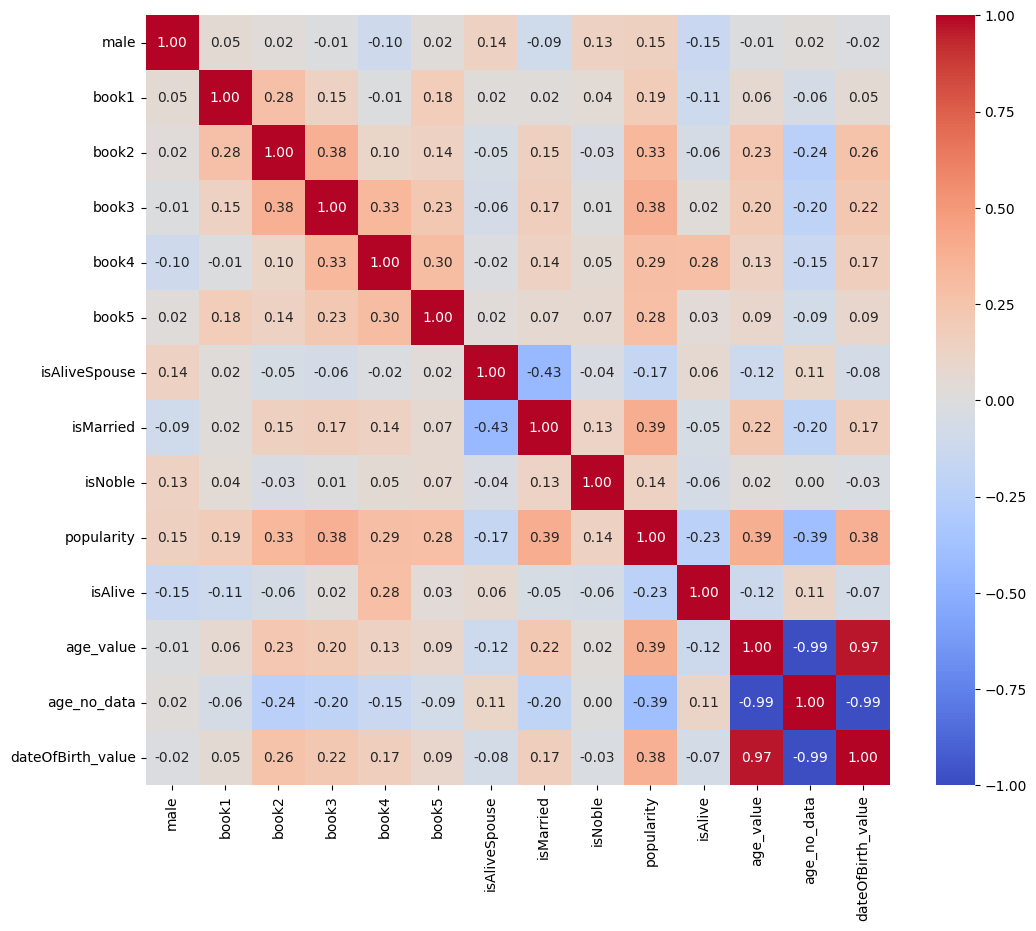

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

In [45]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

correlation_matrix = correlation_matrix.mask(mask)

corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs.sort_values(ascending=False, key=abs)

corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs[:20])

age_value      age_no_data         -0.989309
age_no_data    dateOfBirth_value   -0.986424
age_value      dateOfBirth_value    0.966431
isAliveSpouse  isMarried           -0.433704
isMarried      popularity           0.391896
popularity     age_no_data         -0.391602
               age_value            0.387473
               dateOfBirth_value    0.382001
book2          book3                0.380968
book3          popularity           0.378191
book2          popularity           0.333599
book3          book4                0.329153
book4          book5                0.302338
               popularity           0.292869
               isAlive              0.284014
book5          popularity           0.282492
book1          book2                0.278116
book2          dateOfBirth_value    0.259684
               age_no_data         -0.241263
               age_value            0.232803
dtype: float64


Можно заметить, что есть большая корреляция между возрастом, датой рождения и тем, жив ли персонаж

In [46]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(data.select_dtypes(include='object'))
data_copy = encoder.transform(data.select_dtypes(include='object'))

In [47]:
data

,title,male,house,spouse,book1,book2,book3,book4,book5,isAliveSpouse,isMarried,isNoble,popularity,isAlive,boolDeadRelations,age_value,age_no_data,dateOfBirth_value,culture_grouped
S.No,,,,,,,,,,,,,,,,,,,
1,title_no_data,1,house_no_data,spouse_no_data,0,0,0,0,0,1.0,0,0,1.789123,0,True,0.0,1,0.0,culture_no_data
2,Lord of the Crossing,1,House Frey,Perra Royce,1,1,1,1,1,1.0,1,1,1.957282,1,True,97.0,0,208.0,the Isles and Rivers
3,Ser,1,House Swyft,spouse_no_data,0,0,0,1,0,1.0,0,1,1.443355,1,False,0.0,1,0.0,culture_no_data
4,Queen,0,House Arryn,Viserys I Targaryen,0,0,0,0,0,0.0,1,1,1.287682,0,False,23.0,0,82.0,culture_no_data
5,Greenstone,0,House Santagar,Eldon Estermont,0,0,0,1,0,1.0,1,1,0.728177,1,False,29.0,0,276.0,Dorne
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Archmaester,1,house_no_data,spouse_no_data,1,0,1,1,0,1.0,0,1,1.231814,1,False,0.0,1,0.0,culture_no_data
1554,title_no_data,0,house_no_data,spouse_no_data,1,1,0,0,0,1.0,0,0,0.700130,0,False,0.0,1,0.0,culture_no_data
1555,title_no_data,1,House Seaworth,spouse_no_data,0,1,1,1,1,1.0,0,0,0.939135,0,False,0.0,1,0.0,culture_no_data


In [48]:
text_columns = encoder.get_feature_names_out(data.select_dtypes(include='object').columns)

In [49]:
data = data.drop(data.select_dtypes(include='object').columns, axis=1).copy()

In [50]:
data[text_columns] = data_copy

In [51]:
data.shape

(1557, 726)

### Соберём пайплан в отдельную функцию

In [52]:
def pipeline(data, groups, encoder):
    data["popularity"] = np.log10(data["popularity"] * 100 + 1)
    data['boolDeadRelations'] = np.where(data['numDeadRelations'] > 0, True, False)
    data = data.drop('numDeadRelations', axis=1)

    data['age_value'] = [age if not np.isnan(age) else 0 for age in data['age']]
    data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]
    data = data.drop('age', axis=1)

    data['dateOfBirth_value'] = [date if not np.isnan(date) else 0 for date in data['dateOfBirth']]
    data = data.drop('dateOfBirth', axis=1)

    data['culture_grouped'] = data['culture'].str.lower().map(groups)
    data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')
    data = data.drop('culture', axis=1)

    data = data.drop(['name', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'mother', 'father', 'heir'], axis=1)

    data['title'] = data['title'].fillna('title_no_data')
    data['house'] = data['house'].fillna('house_no_data')

    data['spouse'] = data['spouse'].fillna('spouse_no_data')
    data['isAliveSpouse'] = data['isAliveSpouse'].fillna(data['isAliveSpouse'].mode()[0])

    data_copy = encoder.transform(data.select_dtypes(include='object'))
    text_columns = encoder.get_feature_names_out(data.select_dtypes(include='object').columns)
    data = data.drop(data.select_dtypes(include='object').columns, axis=1).copy()
    data[text_columns] = data_copy

    return data

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [53]:
mask_level0 = corr_pairs.index.get_level_values(0) == 'isAlive'
mask_level1 = corr_pairs.index.get_level_values(1) == 'isAlive'
result = corr_pairs[mask_level0 | mask_level1]
result

book4          isAlive              0.284014
popularity     isAlive             -0.231514
male           isAlive             -0.148290
isAlive        age_value           -0.120206
               age_no_data          0.113629
book1          isAlive             -0.112468
isAlive        dateOfBirth_value   -0.074595
isAliveSpouse  isAlive              0.063894
isNoble        isAlive             -0.060572
book2          isAlive             -0.055998
isMarried      isAlive             -0.049381
book5          isAlive              0.032531
book3          isAlive              0.018427
dtype: float64

Заметим, что бОльшая корреляция у целевой переменной с признаком появляется ли персонаж в 4 книге"

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [54]:
y = data['isAlive']
X = data.drop('isAlive', axis=1)

**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, random_state=42)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [57]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [58]:
# Шаг 1. создание модели
model = LogisticRegression()

# Шаг 2. обучение модели
model.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
model.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [59]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [60]:
# Шаг 3. Предсказание на тестовых данных

# ваш код здесь
y_pred = model.predict(X_val)
# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8109


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [61]:
data_test = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')

По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [62]:
#Подсказка
data_test.loc[data_test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1685,Doreah,NaN,0,Lysene,278279.0,NaN,NaN,NaN,House Targaryen,NaN,...,1,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368
1869,Rhaego,NaN,0,NaN,298299.0,NaN,NaN,NaN,House Targaryen,NaN,...,0,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224


Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [63]:
data_test = pipeline(data_test, cultures_grouped_inverted, encoder)

In [64]:
data_test.head()

,male,book1,book2,book3,book4,book5,isAliveSpouse,isMarried,isNoble,popularity,...,culture_grouped_Old Nations,culture_grouped_Other Nations,culture_grouped_culture_no_data,culture_grouped_the Iron Islands,culture_grouped_the Isles and Rivers,culture_grouped_the Mountain and the Vale,culture_grouped_the North,culture_grouped_the Reach,culture_grouped_the Rock,culture_grouped_the Stormlands
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,1.0,0,0,0.779360,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1559,0,0,1,1,1,1,1.0,0,0,1.878418,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1560,0,0,0,1,1,0,1.0,0,0,0.301756,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1561,1,1,1,1,1,1,1.0,0,1,1.363115,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1562,1,1,1,1,1,1,1.0,1,0,1.648148,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [65]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 8.99MB/s]


In [66]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [67]:
submission['isAlive'] = model.predict(data_test)

In [68]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,1
1561,1
1562,1
...,...
1942,0
1943,1
1944,1


Как сохранить измененный Pandas DataFrame в csv файл:

In [69]:
submission.to_csv("/content/new_submission.csv", index=False)